# Overview

In this demonstration, we are going to compare the Gibbs free energy of graphite and diamond. The class will be split into two groups: one group will study graphite, and the other will study diamond.

Your objective is to report the Gibbs free energy (in eV/atom) for your selected material at 0.001 GPa, 0.1 GPa, and 100 GPa at 4000 K. These calculations can take a minute or two, so you might want to try splitting up the work amongst your groupmates. By the end of this exercise, we will hopefully learn something about the relative stability of these two polymorphs of carbon. Think in advance: what do you expect the answer to be?


# Setup


In [1]:
!uv pip install "git+https://github.com/materialyzeai/matcalc.git" "upet>=0.2.1"

Using Python 3.13.11 environment at: C:\Users\asrosen\AppData\Local\miniconda3\envs\cms
Resolved 89 packages in 601ms
Audited 89 packages in 13ms


We will use the UPET-MAD-1.5 machine learning potential here since it's reasonably accurate and fast. It can be thought of as a drop-in replacement for DFT. We need to download the model checkpoint.


In [2]:
from upet.calculator import UPETCalculator

calc = UPETCalculator(model="pet-mad-s", version="1.5.0")

# Example


## Obtaining the Structure


First, download the corresponding material from the Materials Project, which you can then read in via the `ase.io.read` function.


In [3]:
from ase.io import read

graphite = read("mp-169.cif")
diamond = read("mp-66.cif")

graphite.calc = calc
diamond.calc = calc

## Calculating the Gibbs Free Energies


Now use `matcalc` to predict the Gibbs free energy of your polymorph at the specified conditions. Since we ultimately want to compare the Gibbs free energy of different polymorphs, make sure to normalize your Gibbs free energies on a per-atom basis.


In [4]:
from matcalc import QHACalc

G_diamond = {}
G_graphite = {}
pressures = [0.001, 0.1, 1, 10, 100]
for pressure in pressures:
    qha = QHACalc(
        calc,
        t_min=0,  # K
        t_max=4000,  # K
        fmax=0.01,  # eV/A
        optimizer="BFGS",
        pressure=pressure,  # GPa
        relax_structure=True,
    )
    qha_graphite = qha.calc(graphite)
    qha_diamond = qha.calc(diamond)
    G_diamond[pressure] = qha_diamond["gibbs_free_energies"] / len(diamond)
    G_graphite[pressure] = qha_graphite["gibbs_free_energies"] / len(graphite)
    print(
        f"P = {pressure} GPa | G_graphite - G_diamond = {G_graphite[pressure][-1] - G_diamond[pressure][-1]} eV/atom"
    )

P = 0.001 GPa | G_graphite - G_diamond = -0.22921990379123613 eV/atom
P = 0.1 GPa | G_graphite - G_diamond = -0.22682598872746418 eV/atom
P = 1 GPa | G_graphite - G_diamond = -0.20509854767392888 eV/atom
P = 10 GPa | G_graphite - G_diamond = 0.005497860679257727 eV/atom
P = 100 GPa | G_graphite - G_diamond = 1.7545709283762756 eV/atom


In [5]:
temperatures = qha_diamond["temperatures"][0:-1]
print(f"T = {temperatures[-1]} K")

for pressure in pressures:
    print(
        f"P = {pressure} GPa | G_graphite - G_diamond = {G_graphite[pressure][-1] - G_diamond[pressure][-1]} eV/atom"
    )

T = 3990 K
P = 0.001 GPa | G_graphite - G_diamond = -0.22921990379123613 eV/atom
P = 0.1 GPa | G_graphite - G_diamond = -0.22682598872746418 eV/atom
P = 1 GPa | G_graphite - G_diamond = -0.20509854767392888 eV/atom
P = 10 GPa | G_graphite - G_diamond = 0.005497860679257727 eV/atom
P = 100 GPa | G_graphite - G_diamond = 1.7545709283762756 eV/atom


Text(0, 0.5, 'ΔG (eV/atom)')

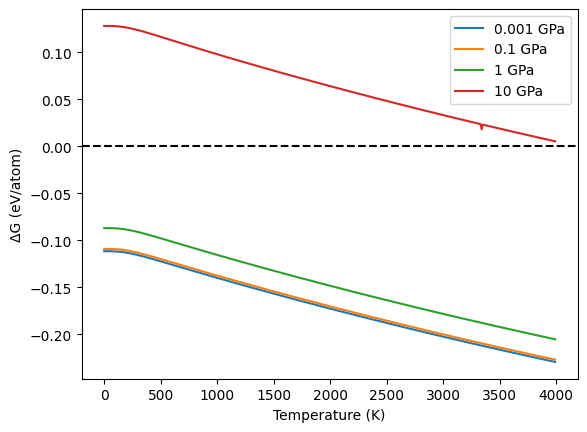

In [ ]:
import matplotlib.pyplot as plt

plt.plot(temperatures, G_graphite[0.001] - G_diamond[0.001], label="0.001 GPa")
plt.plot(temperatures, G_graphite[0.1] - G_diamond[0.1], label="0.1 GPa")
plt.plot(temperatures, G_graphite[1] - G_diamond[1], label="1 GPa")
plt.plot(temperatures, G_graphite[10] - G_diamond[10], label="10 GPa")
plt.axhline(y=0, linestyle="--", color="k")
plt.legend()
plt.xlabel("Temperature (K)")
plt.ylabel("ΔG (eV/atom)")